# Self-Supervised Fisheye Rectification — running the repo's own Quick Start on Kaggle

This notebook runs the **exact steps from the repo's README "Quick start"**:

```
1. git clone https://github.com/memara111/SelfSupervisedFisheyeRectification.git
2. pip3 install -r requirements.txt
3. Prepare dataset -> python3 tools/prepare_cityscapes.py
4. Training       -> python3 src/train.py cfg/cityscapes.yml
5. Testing        -> python3 src/test.py cfg/cityscapes.yml
```

The **only** thing that changes is step 3: the README's version downloads Cityscapes, but we're
using **NYU Depth V2** instead, and NYU has no official `prepare_*.py` script in this repo. So we
write a small `data/nyu2/{train,val,test}.lst` ourselves (same file format `tools/prepare_cityscapes.py`
would have produced) and a matching `cfg/nyu2.yml` (identical hyperparameters to `cfg/cityscapes.yml`).
Steps 1, 2, 4 and 5 are run as the literal shell commands from the README, unmodified.

A few lines of the repo need small patches to actually run (a missing `Loader=` argument for a
newer PyYAML, a `torch.hub` network call that's unreliable on Kaggle, a missing `matplotlib`
import, and `torch.load` calls that need updating for newer PyTorch) — these are applied
automatically in step 2.5 below and don't change the training/testing logic at all.

**Resuming across sessions:** `src/train.py` already checks for `outputs/nyu2/checkpoint.pth.tar`
and resumes from it if present — that's built into the script itself. So stopping the training
cell (or the whole kernel) and re-running it later continues from the last completed epoch with
no extra code needed. To resume in a brand-new Kaggle session, just attach your previous run's
`outputs/` folder as an input dataset and copy `checkpoint.pth.tar` back into
`outputs/nyu2/checkpoint.pth.tar` before re-running the training cell (see the commented-out line
in the config cell below).

## 1. Clone the project

In [ ]:
%cd /kaggle/working
!git clone https://github.com/memara111/SelfSupervisedFisheyeRectification.git
%cd SelfSupervisedFisheyeRectification
!pwd

## 2. Install the dependencies

In [ ]:
!pip3 install -r requirements.txt --break-system-packages -q
print("requirements.txt is empty upstream (no extra pins) - Kaggle's preinstalled "
      "torch / torchvision / opencv / pyyaml / matplotlib already cover everything this repo needs.")

### 2.5 Patch a few lines so the unmodified scripts run on Kaggle

None of these change what the code *does* - they only fix compatibility issues with newer
library versions / Kaggle's environment:

- `src/core/config.py`: `yaml.load(f)` -> newer PyYAML requires an explicit `Loader=`.
- `src/models/pem.py`: `torch.hub.load(...)` -> replaced with the equivalent
  `torchvision.models.vgg11(weights=None)` so building the model doesn't need a live call to
  GitHub every time.
- `src/train.py`: was missing `import matplotlib.pyplot as plt` even though it calls `plt.plot(...)`.
- `src/train.py`, `src/test.py`, `src/predict.py`: `torch.load(model_state_file)` -> add
  `map_location=DEVICE, weights_only=False` (newer PyTorch defaults `weights_only=True`, which
  can't load the optimizer state / loss history stored in these checkpoints).

This cell is idempotent - safe to re-run.

In [ ]:
import re

def patch_file(path, replacements):
    with open(path, "r") as f:
        content = f.read()
    changed = False
    for old, new in replacements:
        if old in content and new not in content:
            content = content.replace(old, new)
            changed = True
    if changed:
        with open(path, "w") as f:
            f.write(content)
    print(("Patched " if changed else "Already patched (or nothing to do): ") + path)

# core/config.py - fix yaml.load missing Loader
patch_file("src/core/config.py", [
    ("self.config = yaml.load(f)", "self.config = yaml.safe_load(f)"),
])

# models/pem.py - avoid torch.hub network dependency
patch_file("src/models/pem.py", [
    ("import torchvision.transforms as transforms",
     "import torchvision.transforms as transforms\nimport torchvision.models as tvmodels"),
    ("            self.vgg = torch.hub.load('pytorch/vision:v0.6.0', 'vgg11', pretrained=False)",
     "            self.vgg = tvmodels.vgg11(weights=None)"),
])

# train.py - missing matplotlib import + robust torch.load
patch_file("src/train.py", [
    ("import argparse\nimport os\nimport torch",
     "import argparse\nimport os\nimport torch\nimport matplotlib\nmatplotlib.use('Agg')\nimport matplotlib.pyplot as plt"),
    ("checkpoint = torch.load(model_state_file)",
     "checkpoint = torch.load(model_state_file, map_location=DEVICE, weights_only=False)"),
])

# test.py / predict.py - robust torch.load
patch_file("src/test.py", [
    ("checkpoint = torch.load(model_file)",
     "checkpoint = torch.load(model_file, map_location=DEVICE, weights_only=False)"),
])
patch_file("src/predict.py", [
    ("checkpoint = torch.load(model_file)",
     "checkpoint = torch.load(model_file, map_location=DEVICE, weights_only=False)"),
])

## 3. Prepare the dataset (NYU Depth V2 instead of Cityscapes)

Builds `data/nyu2/train.lst`, `val.lst` and `test.lst` — one absolute image path per line, which
is exactly the format `DistortDataset` expects (and the same format `tools/prepare_cityscapes.py`
would have produced for Cityscapes). Only the `.jpg` RGB frames are used; the `.png` depth maps
aren't needed for this self-supervised rectification task. The split is done **by scene folder**
so validation/test scenes are fully held out from training, and training images are capped at
`MAX_TRAIN_IMAGES` (10,000 by default).

In [18]:
import os, glob, random

# ----------------------------- EDIT THESE -----------------------------------
DATASET_ROOT = "/kaggle/input/datasets/soumikrakshit/nyu-depth-v2/nyu_data/data/nyu2_train"
MAX_TRAIN_IMAGES = 1000     # hard cap on the number of training images (None = no cap)
VAL_SPLIT = 0.03             # fraction of scenes held out for validation
TEST_SPLIT = 0.03            # fraction of scenes held out for testing
SEED = 42
# ------------------------------------------------------------------------------

random.seed(SEED)

if not os.path.isdir(DATASET_ROOT):
    raise FileNotFoundError(
        f"Couldn't find {DATASET_ROOT}. Double check the dataset is attached to this notebook "
        "and adjust DATASET_ROOT above."
    )

scene_dirs = sorted(d for d in glob.glob(os.path.join(DATASET_ROOT, "*")) if os.path.isdir(d))
random.shuffle(scene_dirs)

n_val = max(1, int(len(scene_dirs) * VAL_SPLIT))
n_test = max(1, int(len(scene_dirs) * TEST_SPLIT))
val_scenes = scene_dirs[:n_val]
test_scenes = scene_dirs[n_val:n_val + n_test]
train_scenes = scene_dirs[n_val + n_test:]

def collect(scenes):
    imgs = []
    for d in scenes:
        imgs.extend(sorted(glob.glob(os.path.join(d, "*.jpg"))))
    return imgs

train_images = collect(train_scenes)
val_images = collect(val_scenes)
test_images = collect(test_scenes)

if MAX_TRAIN_IMAGES is not None and len(train_images) > MAX_TRAIN_IMAGES:
    random.shuffle(train_images)
    train_images = train_images[:MAX_TRAIN_IMAGES]

print(f"{len(scene_dirs)} scenes total -> "
      f"{len(train_images)} train / {len(val_images)} val / {len(test_images)} test images")
assert train_images and val_images and test_images, "No .jpg images found - check DATASET_ROOT."

data_path = "data/nyu2"   # relative to the repo root (matches DATASET.NAME: nyu2 in cfg/nyu2.yml)
os.makedirs(data_path, exist_ok=True)
open(os.path.join(data_path, "train.lst"), "w").write("\n".join(train_images))
open(os.path.join(data_path, "val.lst"), "w").write("\n".join(val_images))
open(os.path.join(data_path, "test.lst"), "w").write("\n".join(test_images))
print("Wrote", os.path.abspath(data_path))

284 scenes total -> 1000 train / 1348 val / 1790 test images
Wrote /kaggle/working/SelfSupervisedFisheyeRectification/data/nyu2


### Write `cfg/nyu2.yml`

Same structure and same hyperparameters as the repo's own `cfg/cityscapes.yml`, just with
`DATASET.NAME: nyu2` so `src/train.py` / `src/test.py` pick up the files written above.

> **Note:** keep `TEST.OUTPUT_SIZE` equal to `DATASET.HEIGHT/WIDTH` (as done here, and as
> `cfg/cityscapes.yml` does). `src/test.py` has a latent bug where it builds the reconstruction
> effector at `OUTPUT_SIZE` but feeds it an image still sized at `DATASET.HEIGHT/WIDTH`, which
> crashes with a tensor size mismatch if the two ever differ.

In [20]:
nyu2_yml = '''DATASET:
  NAME: nyu2
  HEIGHT: 144
  WIDTH: 256
TRAIN:
  MAX_EPOCH: 1000
  BATCH_SIZE: 16
  LEARNING_RATE: 0.0001
  CURRICULUM:
    ENABLED: true
    SWITCH_EPOCH: 30
TEST:
  CHECKPOINT: checkpoint.pth.tar
  SAVE_RESULTS: true
  OUTPUT_SIZE:
    HEIGHT: 144
    WIDTH: 256
'''

os.makedirs("cfg", exist_ok=True)
with open("cfg/nyu2.yml", "w") as f:
    f.write(nyu2_yml)
print(open("cfg/nyu2.yml").read())

DATASET:
  NAME: nyu2
  HEIGHT: 144
  WIDTH: 256
TRAIN:
  MAX_EPOCH: 1000
  BATCH_SIZE: 16
  LEARNING_RATE: 0.0001
  CURRICULUM:
    ENABLED: true
    SWITCH_EPOCH: 30
TEST:
  CHECKPOINT: checkpoint.pth.tar
  SAVE_RESULTS: true
  OUTPUT_SIZE:
    HEIGHT: 144
    WIDTH: 256



## 4. Training

This is the literal command from the README, just pointed at our config:

```
python3 src/train.py cfg/nyu2.yml
```

Checkpoints (model + optimizer + full loss history) are written to
`outputs/nyu2/checkpoint.pth.tar` after **every** epoch by the script itself, and it
auto-resumes from that file if it already exists. So if you stop this cell (or the kernel session
ends), just re-run it later and it picks up from the last completed epoch — no extra logic needed
on our end, it's a property of `src/train.py` itself.

`MAX_EPOCH: 1000` is long by design (matches the README's default) — expect to need multiple
Kaggle sessions to get all the way through it.

In [21]:
# If resuming in a *new* Kaggle session, uncomment and point this at your previous run's
# checkpoint (e.g. attached as an input dataset via "Add Data" -> "Notebook Output Files"):
#
# import shutil
# os.makedirs("outputs/nyu2", exist_ok=True)
# shutil.copy("/kaggle/input/my-fisheye-checkpoint/checkpoint.pth.tar", "outputs/nyu2/checkpoint.pth.tar")

!python3 src/train.py cfg/nyu2.yml

torch.cuda.is_available(): True
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 142, 254]           1,792
            Conv2d-2         [-1, 64, 142, 254]           1,792
            Conv2d-3         [-1, 64, 140, 252]          36,928
            Conv2d-4         [-1, 64, 140, 252]          36,928
         MaxPool2d-5          [-1, 64, 70, 126]               0
         MaxPool2d-6          [-1, 64, 70, 126]               0
            Conv2d-7         [-1, 128, 68, 124]          73,856
            Conv2d-8         [-1, 128, 68, 124]          73,856
            Conv2d-9         [-1, 128, 66, 122]         147,584
           Conv2d-10         [-1, 128, 66, 122]         147,584
        MaxPool2d-11          [-1, 128, 33, 61]               0
        MaxPool2d-12          [-1, 128, 33, 61]               0
  ConvTranspose2d-13          [-1, 64, 66, 122]          32,832
  ConvT

## 5. Plot the train / val loss

`src/train.py` already saves `outputs/nyu2/losses.png` after every epoch — this just displays it.

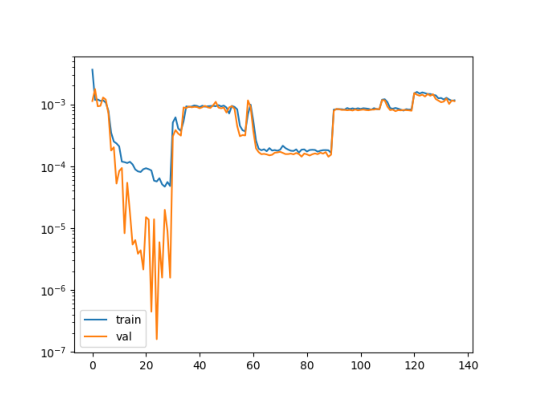

Saved at /kaggle/working/SelfSupervisedFisheyeRectification/outputs/nyu2/losses.png


In [22]:
import matplotlib.pyplot as plt
from PIL import Image

losses_png = "outputs/nyu2/losses.png"
plt.figure(figsize=(8, 5))
plt.imshow(Image.open(losses_png))
plt.axis("off")
plt.show()
print("Saved at", os.path.abspath(losses_png))

### Optional: re-plot from the checkpoint directly

Gives you the raw numbers / a cleaner interactive figure instead of the saved PNG, using the
same `train_losses` / `val_losses` lists `src/train.py` stores in the checkpoint every epoch.

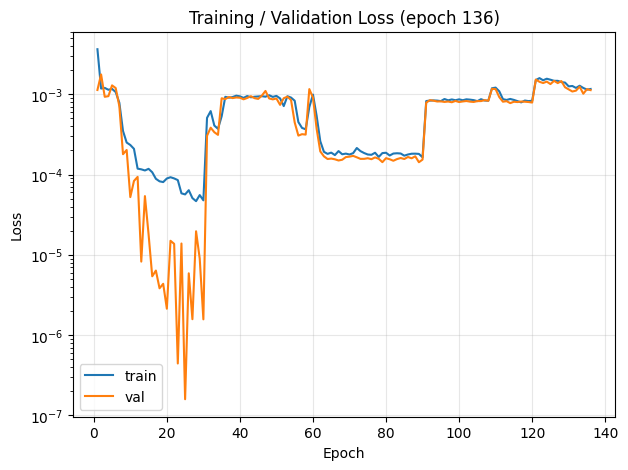

In [23]:
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
ckpt = torch.load("outputs/nyu2/checkpoint.pth.tar", map_location=DEVICE, weights_only=False)
train_losses, val_losses = ckpt["train_losses"], ckpt["val_losses"]

plt.figure(figsize=(7, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, label="train")
plt.plot(range(1, len(val_losses) + 1), val_losses, label="val")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.yscale("log")
plt.title(f"Training / Validation Loss (epoch {ckpt['epoch']})")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## 6. Testing

Again, the literal command from the README:

```
python3 src/test.py cfg/nyu2.yml
```

This runs the trained model on the held-out `data/nyu2/test.lst` images, applies a fresh random
synthetic distortion to each, predicts the distortion parameter, and (since `TEST.SAVE_RESULTS:
true`) saves three images per test sample to `results/`: `{idx}_org.jpg` (clean original),
`{idx}_dis.jpg` (synthetically distorted input), and `{idx}_rec.jpg` (the model's rectification).

In [ ]:
!python3 src/test.py cfg/nyu2.yml

In [24]:
import glob

result_ids = sorted({os.path.basename(p).split("_")[0] for p in glob.glob("results/*_org.jpg")},
                     key=int)[:4]

fig, axes = plt.subplots(len(result_ids), 3, figsize=(10, 3 * len(result_ids)))
if len(result_ids) == 1:
    axes = [axes]
for row, idx in zip(axes, result_ids):
    row[0].imshow(Image.open(f"results/{idx}_org.jpg")); row[0].set_title("Original"); row[0].axis("off")
    row[1].imshow(Image.open(f"results/{idx}_dis.jpg")); row[1].set_title("Distorted"); row[1].axis("off")
    row[2].imshow(Image.open(f"results/{idx}_rec.jpg")); row[2].set_title("Rectified"); row[2].axis("off")
plt.tight_layout()
plt.show()

ValueError: Number of rows must be a positive integer, not 0

<Figure size 1000x0 with 0 Axes>

## 7. Bonus: undistort your own fisheye photo

`test.py` above only works on synthetically-distorted NYU test images. To rectify an actual photo
of yours, the repo provides `src/predict.py` (not part of the README's Quick start, but built for
exactly this): it takes a directory of real images and doesn't need a known ground-truth
distortion.

```
python3 src/predict.py cfg/nyu2.yml -i <input_dir> -oh <height> -ow <width>
```

In [27]:
# ----------------------------- EDIT THIS -------------------------------------
MY_IMAGE_PATH = "/kaggle/input/datasets/qweasd123456785432/im-calib/im_calib/im_calib_01.jpg"  # <- set to your image
# -------------------------------------------------------------------------------

import shutil

infer_input_dir = "/kaggle/working/my_photo"
os.makedirs(infer_input_dir, exist_ok=True)
shutil.copy(MY_IMAGE_PATH, os.path.join(infer_input_dir, os.path.basename(MY_IMAGE_PATH)))

!python3 src/predict.py cfg/nyu2.yml -i {infer_input_dir} -oh 1080 -ow 1920

torch.cuda.is_available(): True
=> load outputs/nyu2/checkpoint.pth.tar
Got -0.0872713178396225 for ('/kaggle/working/my_photo/im_calib_01.jpg',)
FisheyeEffector was initialized with distortion = -0.0872713178396225


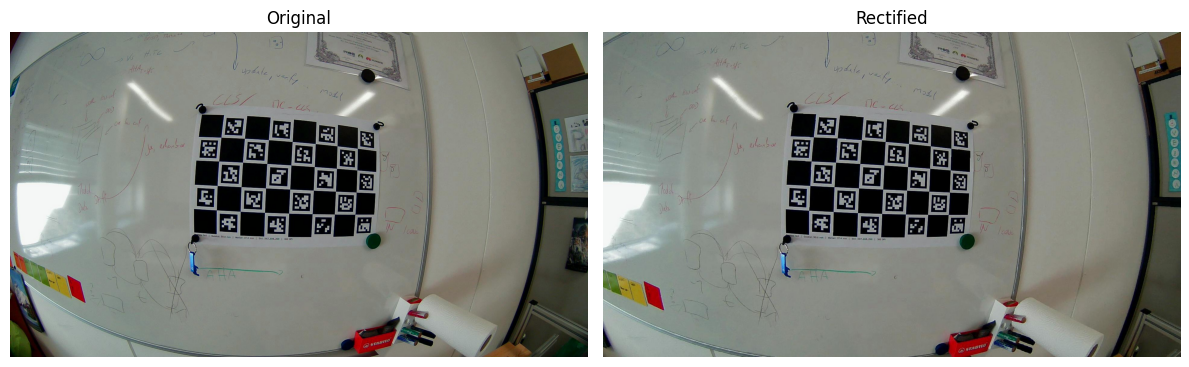

Rectified image saved to /kaggle/working/my_photo/out/im_calib_01.jpg


In [28]:
filename = os.path.basename(MY_IMAGE_PATH)
original_path = os.path.join(infer_input_dir, filename)
rectified_path = os.path.join(infer_input_dir, "out", filename)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(Image.open(original_path)); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(Image.open(rectified_path)); axes[1].set_title("Rectified"); axes[1].axis("off")
plt.tight_layout()
plt.show()

print("Rectified image saved to", os.path.abspath(rectified_path))